In [ ]:
#################################################################
# PIPELINE: SINGLE-STAGE TCN (UNBALANCED)
# TÍNH NĂNG: Cửa sổ trượt 3D -> Scaling -> Train Multiclass gốc
#################################################################

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & LỌC ĐẶC TRƯNG GỐC 
# ==============================================================================
print("\n[1/5] Đang đọc Parquet, làm sạch dữ liệu và phân loại đặc trưng...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet' # Cập nhật path nếu cần
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# --- 🔥 SỬA LỖI TẠI ĐÂY: QUY ĐỔI EPOCH TIME (GIÂY) SANG DATETIME ---
try:
    # Đảm bảo cột là dạng số trước khi convert
    df['starttime'] = pd.to_numeric(df['starttime'], errors='coerce')
    # Chuyển đổi từ số giây (unit='s') sang định dạng chuẩn
    df['starttime'] = pd.to_datetime(df['starttime'], unit='s')
except Exception as e:
    print(f"[!] Cảnh báo khi chuyển đổi thời gian: {e}")

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
drop_cols = exclude_cols

feature_cols = [c for c in df.columns if c not in drop_cols]

# Xử lý các cột dạng chuỗi thành số
orig_cat_cols = df[feature_cols].select_dtypes(include=["object", "string", "category"]).columns.tolist()
for col in orig_cat_cols:
    df[col] = df[col].astype('category').cat.codes

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Khai báo nhóm cột Phân loại (Categorical/Binary)
cat_binary_cols_manual = [
    'isworkhour', 'isafterhour', 'isweekend', 'isweekendafterhour', 'pc', 'n_logon',
    'ITAdmin', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'start_with', 'end_with'
]
cat_binary_cols = [c for c in cat_binary_cols_manual if c in feature_cols]
numeric_cols = [c for c in feature_cols if c not in cat_binary_cols]

print(f"-> Đã xác định {len(feature_cols)} đặc trưng hợp lệ (Trong đó: {len(numeric_cols)} Liên tục, {len(cat_binary_cols)} Phân loại).")

# ==============================================================================
# 2️⃣ CHIA DỮ LIỆU THEO THỜI GIAN (TIME-BASED SPLIT)
# ==============================================================================
print("\n[2/5] Đang cắt chia dữ liệu theo Trục thời gian (64% - 16% - 20%)...")
df = df.sort_values(by='starttime').reset_index(drop=True)

n_total = len(df)
train_end = int(n_total * 0.64)  
val_end   = int(n_total * 0.80)  

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

# --- BÁO CÁO KIỂM TOÁN (AUDIT REPORT) 1: THỜI GIAN & PHÂN BỔ NHÃN TRƯỚC WINDOW ---
print("\n" + "-"*60)
print("📊 BÁO CÁO KIỂM TOÁN TẬP DỮ LIỆU (TRƯỚC SLIDING WINDOW)")
print("-"*60)
print(f"Tập TRAIN ({len(df_train):,} mẫu):")
print(f"  > Thời gian: {df_train['starttime'].min()}  -->  {df_train['starttime'].max()}")
print(f"  > Phân bổ nhãn: {df_train['insider'].value_counts().to_dict()}")

print(f"\nTập VAL ({len(df_val):,} mẫu):")
print(f"  > Thời gian: {df_val['starttime'].min()}  -->  {df_val['starttime'].max()}")
print(f"  > Phân bổ nhãn: {df_val['insider'].value_counts().to_dict()}")

print(f"\nTập TEST ({len(df_test):,} mẫu):")
print(f"  > Thời gian: {df_test['starttime'].min()}  -->  {df_test['starttime'].max()}")
print(f"  > Phân bổ nhãn: {df_test['insider'].value_counts().to_dict()}")
print("-"*60)

del df; gc.collect()

# ==============================================================================
# 3️⃣ TIỀN XỬ LÝ SÂU: DROP DEAD + DROP SPARSE + LOG SKEW + SCALE
# ==============================================================================

print("\n[3/5] Đang thực hiện Deep Preprocessing (Fixed Pipeline)...")
# ------------------------------------------------------------------------------
# STEP 1: DROP ZERO VARIANCE (DEAD COLUMNS)
# ------------------------------------------------------------------------------

valid_numeric_cols = [col for col in numeric_cols if df_train[col].std() > 0]
dead_cols = list(set(numeric_cols) - set(valid_numeric_cols))
print(f"  -> Gỡ bỏ {len(dead_cols)} cột 'Zombie' (0 variance)")
df_train.drop(columns=dead_cols, inplace=True)
df_val.drop(columns=dead_cols, inplace=True)
df_test.drop(columns=dead_cols, inplace=True)
numeric_cols = valid_numeric_cols

# ------------------------------------------------------------------------------
# STEP 2: DROP SPARSE FEATURES (>98% ZERO)
# ------------------------------------------------------------------------------
# sparse_cols = [col for col in numeric_cols if (df_train[col] == 0).mean() > 0.98]
# print(f"  -> Gỡ bỏ {len(sparse_cols)} cột quá thưa (>98% zero)")
# df_train.drop(columns=sparse_cols, inplace=True)
# df_val.drop(columns=sparse_cols, inplace=True)
# df_test.drop(columns=sparse_cols, inplace=True)
# numeric_cols = [col for col in numeric_cols if col not in sparse_cols]

# ------------------------------------------------------------------------------
# STEP 3: PHÂN LOẠI SKEWED / NORMAL FEATURES
# ------------------------------------------------------------------------------
skewed_cols = [col for col in numeric_cols if abs(df_train[col].skew()) > 3]
normal_cols = [col for col in numeric_cols if col not in skewed_cols]
print(f"  -> {len(skewed_cols)} cột bị skew mạnh (|skew| > 3)")
print(f"  -> {len(normal_cols)} cột phân phối tương đối bình thường")

# ------------------------------------------------------------------------------
# STEP 4: SIGNED LOG TRANSFORM (CHO SKEWED FEATURES)
# ------------------------------------------------------------------------------
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))
print(f"  -> Áp dụng Signed Log Transform cho {len(skewed_cols)} cột")
for col in skewed_cols:
    df_train[col] = signed_log(df_train[col])
    df_val[col]   = signed_log(df_val[col])
    df_test[col]  = signed_log(df_test[col])

# ------------------------------------------------------------------------------
# STEP 5: MINMAX SCALE CHO SKEWED FEATURES
# ------------------------------------------------------------------------------
minmax = MinMaxScaler()
if len(skewed_cols) > 0:
    df_train[skewed_cols] = minmax.fit_transform(df_train[skewed_cols])
    df_val[skewed_cols]   = minmax.transform(df_val[skewed_cols])
    df_test[skewed_cols]  = minmax.transform(df_test[skewed_cols])

# ------------------------------------------------------------------------------
# STEP 6: STANDARD SCALE CHO NORMAL FEATURES
# ------------------------------------------------------------------------------
scaler = StandardScaler()
if len(normal_cols) > 0:
    df_train[normal_cols] = scaler.fit_transform(df_train[normal_cols])
    df_val[normal_cols]   = scaler.transform(df_val[normal_cols])
    df_test[normal_cols]  = scaler.transform(df_test[normal_cols])

# ------------------------------------------------------------------------------
# STEP 7: AUDIT SAU PREPROCESSING
# ------------------------------------------------------------------------------
stats_df_after = pd.DataFrame({
    'Max': df_train[numeric_cols].max(),
    'Mean': df_train[numeric_cols].mean(),
    'Std': df_train[numeric_cols].std(),
    'Skewness': df_train[numeric_cols].skew()
}).round(4)

feature_cols = cat_binary_cols + numeric_cols
print(f"✅ Đã chốt hạ danh sách đầu vào cho Model: {len(feature_cols)} features hợp lệ.")

print("\n" + "-"*85)
print("🔎 BÁO CÁO KIỂM TOÁN SAU PREPROCESSING")
print("-"*85)
print(f"  > Số feature còn lại: {len(numeric_cols)}")
print(f"  > Max tuyệt đối toàn tập: {stats_df_after['Max'].abs().max():.4f}")
print(f"  > Mean trung bình: {stats_df_after['Mean'].mean():.4f}")
print(f"  > Std trung bình: {stats_df_after['Std'].mean():.4f}")
print(f"  > Cột còn skew mạnh (|skew| > 3): {len(stats_df_after[stats_df_after['Skewness'].abs() > 3])}")
print("-"*85)

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW (Cho Deep Learning)
# ==============================================================================
print("\n[4/5] Đang cuộn dữ liệu thành Tensor 3D...")

def create_sliding_windows_3D(df_subset, window_size=3):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []

    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size] 
            window_label = labels[i + window_size - 1]
            #window_label = np.max(labels[i : i + window_size])
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 4
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)

# --- BÁO CÁO KIỂM TOÁN (AUDIT REPORT) 2: SHAPE 3D & PHÂN BỔ NHÃN SAU WINDOW ---
print("\n" + "-"*60)
print("📦 BÁO CÁO KIỂM TOÁN TENSOR 3D (SAU SLIDING WINDOW)")
print("-"*60)
print(f"Tập TRAIN Tensor: {X_train.shape}")
print(f"  > Giải thích: {X_train.shape[0]:,} (Mẫu) x {X_train.shape[1]} (Time steps) x {X_train.shape[2]} (Đặc trưng gốc/bước)")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_train, return_counts=True)))}")

print(f"\nTập VAL Tensor: {X_val.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_val, return_counts=True)))}")

print(f"\nTập TEST Tensor: {X_test.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_test, return_counts=True)))}")
print("-"*60)

# =====================================================
# 5️⃣ XÂY DỰNG VÀ HUẤN LUYỆN LSTM ĐA LỚP
# =====================================================
print(f"\n[TRAINING] Huấn luyện Baseline TCN Multiclass (Train: {len(y_train)} mẫu gốc)...")

T = X_train.shape[1]
F = X_train.shape[2]

# Xây dựng kiến trúc TCN thuần túy bằng Keras
model = Sequential([
    # TCN Block 1: Dilation = 1 (Nhìn các bước liền kề)
    # padding='causal' là linh hồn của TCN, đảm bảo không rò rỉ dữ liệu từ tương lai về quá khứ
    Conv1D(filters=128, kernel_size=2, padding='causal', dilation_rate=1, activation='relu', input_shape=(T,F)),
    BatchNormalization(),
    Dropout(0.3),
    
    # TCN Block 2: Dilation = 2 (Nhìn cách đoạn để mở rộng tầm nhìn)
    Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=2, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # TCN Block 3: Dilation = 4 (Tiếp tục mở rộng Receptive Field)
    # Vì Window Size hiện tại là 3 nên block này có thể là hơi dư, nhưng tôi để sẵn 
    # để nếu sau này bạn tăng Window Size lên 5 hoặc 10, mạng vẫn tự động học cực tốt!
    # Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=4, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.3),

    # Ép phẳng mảng 3D thành 1D để đưa vào tầng phân loại
    Flatten(),
    
    # Tầng Dense (Fully Connected) phân loại
    Dense(32, activation='relu'), 
    BatchNormalization(),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), # Chỉnh LR lên 1e-4 vì TCN học mượt hơn LSTM
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

custom_weight = {
    0: 1.0,
    1: 20.0,
    2: 50.0,
    3: 30.0
}

start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, 
    batch_size=1024, 
    class_weight=custom_weight,
    callbacks=[early_stop],
    verbose=1
)
print(f"✅ Hoàn thành Huấn luyện TCN! Thời gian: {time.time() - start_time:.2f} giây.")

# =====================================================
# 6️⃣ INFERENCE VÀ ĐÁNH GIÁ (ARGMAX CƠ BẢN)
# =====================================================
print("\n[INFERENCE] Đang dự đoán trên tập Test...")
prob_test = model.predict(X_test)

final_preds = np.argmax(prob_test, axis=1)

print("\n========== CLASSIFICATION REPORT (TCN) ==========")
print(classification_report(y_test, final_preds, digits=4, zero_division=0))

cm = confusion_matrix(y_test, final_preds, normalize="true")
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["Benign","Scenario 1","Scenario 2","Scenario 3"], 
            yticklabels=["Benign","Scenario 1","Scenario 2","Scenario 3"])
plt.title("Confusion Matrix - Unbalance TCN", fontweight='bold')
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ LEARNING CURVE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TCN: TEMPORAL CONVOLUTIONAL NETWORK', fontsize=14, fontweight='bold', y=1.05)

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
axes[0].set_title('TCN: Loss', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
axes[1].set_title('TCN: Accuracy', fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
#################################################################
# TCN PHÂN TẦNG BINARY -> MULTICLASS
#################################################################

import pandas as pd
import numpy as np
import gc, random, os, time
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# --- HÀM VẼ BIỂU ĐỒ LEARNING CURVE ---
def plot_learning_curves(history, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Biểu đồ Loss
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    ax[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax[0].set_title(f'{title_prefix} - Loss Curve', fontweight='bold')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True, linestyle=':', alpha=0.6)
    
    # Biểu đồ Accuracy
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
    
    ax[1].plot(history.history[acc_key], label='Train Acc', color='blue')
    ax[1].plot(history.history[val_acc_key], label='Val Acc', color='orange')
    ax[1].set_title(f'{title_prefix} - Accuracy Curve', fontweight='bold')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. ĐỌC DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/4] Đang đọc file, chia tập và Scale dữ liệu...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))

df_train, df_val, df_test = split_user_time_multiclass(df)

dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 2. TẠO TENSOR 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Nhãn Max Label)...")

def create_sliding_windows_3D(df_subset, window_size=5):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        for i in range(len(group) - window_size + 1):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE)

N_train, T, F = X_train.shape
del df_train, df_val, df_test; gc.collect()

def build_bilstm(is_binary=False):
    model = Sequential([
        Conv1D(filters=128, kernel_size=2, padding='causal', dilation_rate=1, activation='relu', input_shape=(T,F)), BatchNormalization(), Dropout(0.3),
    
        # TCN Block 2: Dilation = 2 (Nhìn cách đoạn để mở rộng tầm nhìn)
        Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=2, activation='relu'), BatchNormalization(), Dropout(0.3),

        #Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=4, activation='relu'), BatchNormalization(), Dropout(0.3),

        # Ép phẳng mảng 3D thành 1D để đưa vào tầng phân loại
        Flatten(),
    
        # Tầng Dense (Fully Connected) phân loại
        Dense(32, activation='relu'), BatchNormalization()
    ])
    if is_binary:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'])
    else:
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy',
            metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy'])
    return model


# ==============================================================================
# 3. TẦNG 1: BINARY GATEKEEPER
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN BINARY GATEKEEPER")
print("="*75)

y_train_t1, y_val_t1 = (y_train > 0).astype(int), (y_val > 0).astype(int)
class_weight_t1 = {0: 1.0, 1: 300.0}

start_time_t1 = time.time()
model_t1 = build_bilstm(is_binary=True)
history_t1 = model_t1.fit(
    X_train, y_train_t1, validation_data=(X_val, y_val_t1), class_weight=class_weight_t1, 
    epochs=150, batch_size=512, verbose=1,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5)]
)
total_time_t1 = time.time() - start_time_t1
# Vẽ biểu đồ Tầng 1
plot_learning_curves(history_t1, "TẦNG 1 (Binary)")

# --- DÒ TÌM THRESHOLD TẦNG 1 ---
print("\n🔍 Đang ép Threshold Tầng 1 (Trừ hao Domain Shift cho tập Test)...")
probs_val_t1 = model_t1.predict(X_val).flatten()

best_threshold_t1 = 0.01 
best_recall, best_fpr = 0.0, 1.0
TARGET_RECALL_VAL = 0.97

for thresh in np.arange(0.99, 0.00, -0.01):
    preds_tmp = (probs_val_t1 >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_t1, preds_tmp, labels=[0, 1]).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if recall >= TARGET_RECALL_VAL:
        best_threshold_t1 = thresh
        best_recall = recall
        best_fpr = fpr
        break 

if best_threshold_t1 > 0.20:
    best_threshold_t1 = 0.15 

THRESHOLD_T1 = best_threshold_t1
print(f"-> 🏆 Chốt Threshold Tầng 1 = {THRESHOLD_T1:.2f}")

# ==============================================================================
# 4. CHUẨN BỊ DATA & TRAIN TẦNG 2
# ==============================================================================
print("\n" + "="*75)
print("🔵 CHUẨN BỊ DỮ LIỆU VÀ TRAIN TẦNG 2 (TẠO RANH GIỚI MỎ NEO BENIGN)")
print("="*75)

probs_train_t1 = model_t1.predict(X_train).flatten()
attack_mask = (y_train > 0)
hard_mask = (y_train == 0) & (probs_train_t1 >= THRESHOLD_T1)
benign_indices = np.where(y_train == 0)[0]
np.random.shuffle(benign_indices)
random_mask = np.zeros_like(y_train, dtype=bool)
random_mask[benign_indices[:int(0.3 * len(benign_indices))]] = True

mask_train_t2 = attack_mask | hard_mask | random_mask
X_train_t2, y_train_t2 = X_train[mask_train_t2], y_train[mask_train_t2]

probs_val_t1_t2 = model_t1.predict(X_val).flatten()
hard_val_mask = (y_val == 0) & (probs_val_t1_t2 >= THRESHOLD_T1)
benign_val_idx = np.where(y_val == 0)[0]
np.random.shuffle(benign_val_idx)
random_val_mask = np.zeros_like(y_val, dtype=bool)
random_val_mask[benign_val_idx[:int(0.3 * len(benign_val_idx))]] = True

val_mask_t2 = (y_val > 0) | hard_val_mask | random_val_mask
X_val_t2, y_val_t2 = X_val[val_mask_t2], y_val[val_mask_t2]

class_weight_t2 = {0: 1.0, 1: 5.0, 2: 150.0, 3: 100.0} 
y_train_t2_onehot = tf.keras.utils.to_categorical(y_train_t2, num_classes=4)
y_val_t2_onehot   = tf.keras.utils.to_categorical(y_val_t2, num_classes=4)

start_time_t2 = time.time()
model_t2 = build_bilstm(is_binary=False)
es_t2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_t2 = model_t2.fit(
    X_train_t2, y_train_t2_onehot, 
    validation_data=(X_val_t2, y_val_t2_onehot),
    class_weight=class_weight_t2, 
    epochs=150, batch_size=256, verbose=1, callbacks=[es_t2, ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)]
)

# 🔴 CHỐT THỜI GIAN
total_time_t2 = time.time() - start_time_t2
print(f"\n⏱️ TỔNG THỜI GIAN HUẤN LUYỆN (Tầng 1 + Tầng 2): {(total_time_t2 + total_time_t1)/60:.2f} Phút")

# Vẽ biểu đồ Tầng 2
plot_learning_curves(history_t2, "TẦNG 2 (Multiclass)")

# ==============================================================================
# 5. ĐÁNH GIÁ TẦNG 1 TRÊN TẬP TEST (Trước khi đẩy xuống T2)
# ==============================================================================
print("\n" + "="*75)
print("🛡️ KIỂM TRA SỨC MẠNH GÁC CỔNG CỦA TẦNG 1 TRÊN TẬP TEST")
print("="*75)

probs_test_t1 = model_t1.predict(X_test).flatten()
preds_test_t1 = (probs_test_t1 >= THRESHOLD_T1).astype(int)
y_test_binary = (y_test > 0).astype(int)

print("\nBáo cáo phân loại TẦNG 1 (Test Set):")
print(classification_report(y_test_binary, preds_test_t1, target_names=['Benign', 'Attack'], digits=4))

cm_t1 = confusion_matrix(y_test_binary, preds_test_t1)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title(f'Tầng 1 - Confusion Matrix', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

# ==============================================================================
# 6. KHÁM NGHIỆM TRÊN TẬP TEST (CONSERVATIVE CASCADE T2)
# ==============================================================================
print("\n" + "="*75)
print("🏆 KHÁM NGHIỆM CHUNG CUỘC: LUẬT ÉP CUNG TỘI PHẠM (THRESHOLD = 0.9)")
print("="*75)

final_preds = np.zeros(len(y_test), dtype=int)
suspect_indices = np.where(probs_test_t1 >= THRESHOLD_T1)[0]

if len(suspect_indices) > 0:
    X_test_suspects = X_test[suspect_indices]
    probs_t2 = model_t2.predict(X_test_suspects)
    preds_t2 = np.zeros(len(probs_t2), dtype=int)
    
    THRESHOLD = 0.98
    
    for i in range(len(probs_t2)):
        if probs_t2[i, 0] >= THRESHOLD:
            preds_t2[i] = 0 # Tha bổng
        else:
            preds_t2[i] = np.argmax(probs_t2[i, 1:]) + 1 # Ép tội
            
    final_preds[suspect_indices] = preds_t2

# ==============================================================================
# BÁO CÁO CUỐI CÙNG
# ==============================================================================
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG (FINAL REPORT):")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final Confusion Matrix ', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

2026-04-07 13:32:36.607563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775568756.998093      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775568757.114904      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775568758.141608      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775568758.141667      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775568758.141670      55 computation_placer.cc:177] computation placer alr


[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...

[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...
 -> Đã ép 8 cột Categorical thành Tần suất (Có Smoothing đáy 1%).
 -> Đã Scale chuẩn hóa 99 cột Numeric.
 -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: 107 (Hoàn hảo!)

[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...



🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)
-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...
✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!


I0000 00:00:1775568807.850774      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775568807.856703      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1775568813.421200     137 service.cc:152] XLA service 0x6827d1a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775568813.421246     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775568813.421250     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775568814.195923     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


 35/235 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2130 - auc: 0.4764 - loss: 0.4085

I0000 00:00:1775568820.775934     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.2378 - auc: 0.5062 - loss: 0.3875 - val_accuracy: 0.1364 - val_auc: 0.7098 - val_loss: 0.2511 - learning_rate: 1.0000e-05
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3415 - auc: 0.6192 - loss: 0.2982 - val_accuracy: 0.6475 - val_auc: 0.8202 - val_loss: 0.1247 - learning_rate: 1.0000e-05
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4349 - auc: 0.7031 - loss: 0.2362 - val_accuracy: 0.7322 - val_auc: 0.8558 - val_loss: 0.0974 - learning_rate: 1.0000e-05
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5106 - auc: 0.7645 - loss: 0.1952 - val_accuracy: 0.7627 - val_auc: 0.8736 - val_loss: 0.0856 - learning_rate: 1.0000e-05
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5651 - auc: 0.8060 - loss: 0.1674 - val_accuracy: 0.7844 - val_auc: 0.8857 - val_loss: 0.0768 - learning_rate: 1.0000e-05
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 

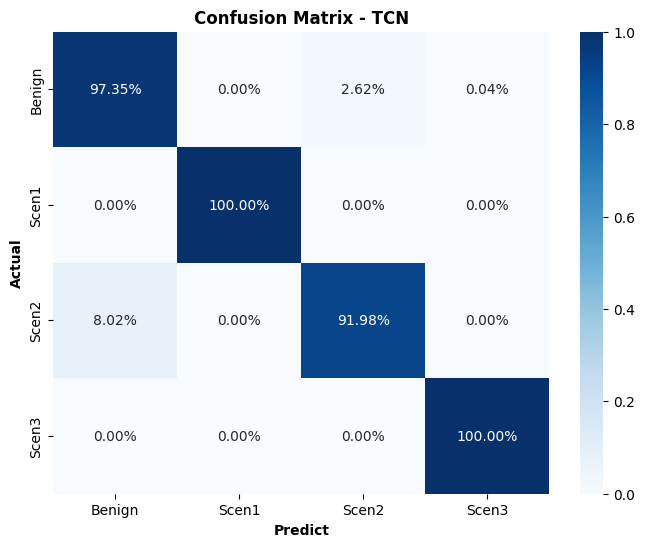


-> [MÀNG LỌC VỚT] Tầng 2 đã soi 87937 mẫu Benign và lôi cổ thêm được:
   + 1214 mẫu Scen2 ẩn mình (Ngưỡng 0.3)!

🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)
              precision    recall  f1-score   support

      Benign     0.9999    0.9601    0.9796     90321
       Scen1     1.0000    1.0000    1.0000        35
       Scen2     0.0416    0.9568    0.0798       162
       Scen3     0.2045    1.0000    0.3396         9

    accuracy                         0.9601     90527
   macro avg     0.5615    0.9792    0.5997     90527
weighted avg     0.9981    0.9601    0.9779     90527



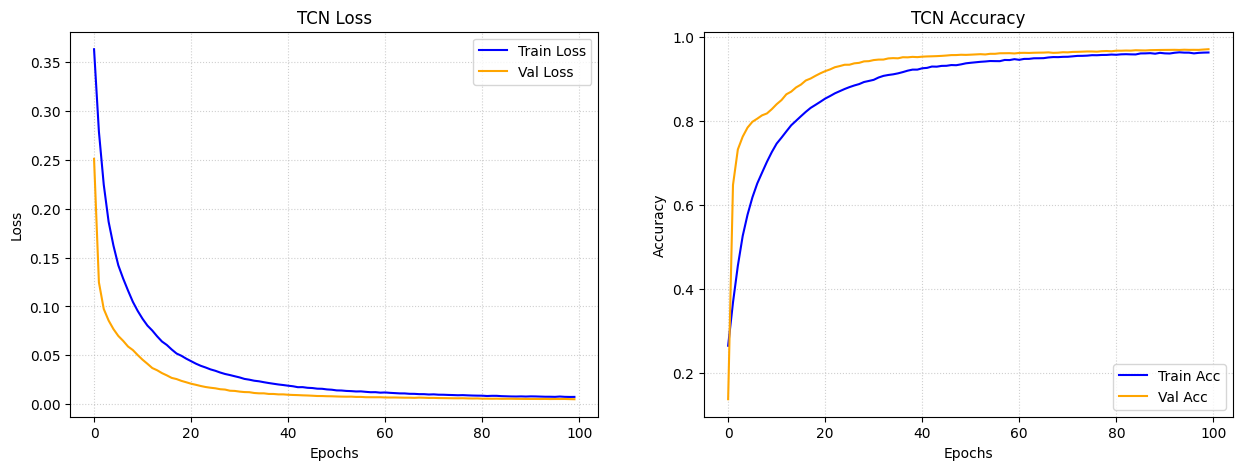

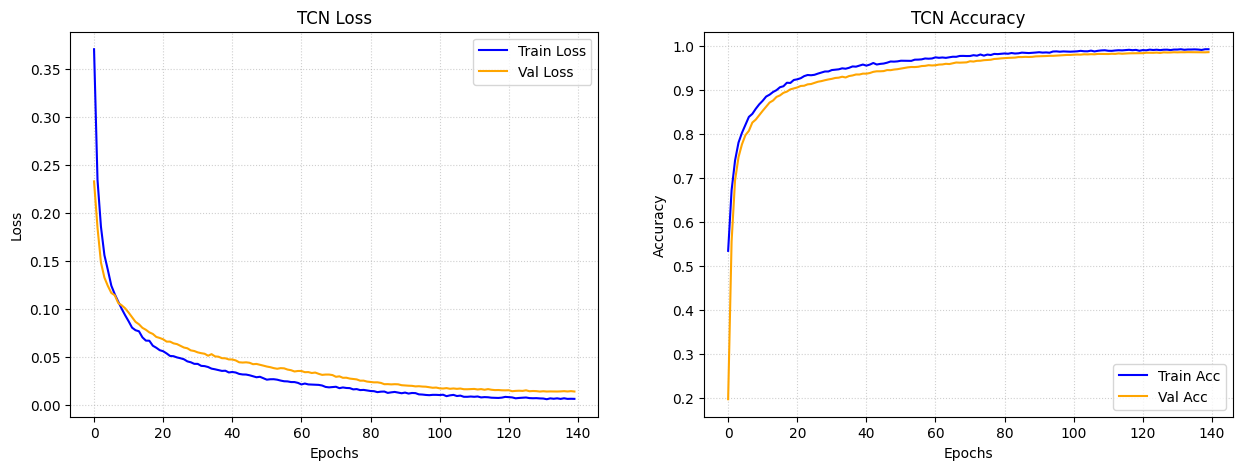

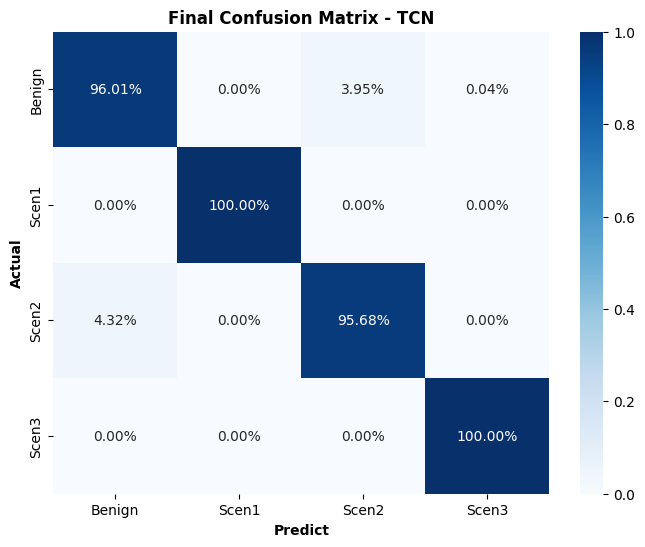

In [1]:
#TCN Cân Bằng RUS+SMOTE (Tích hợp AUC & Vẽ biểu đồ 3 trục)
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
import time
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy, BinaryFocalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Conv1D, Flatten, GlobalMaxPooling1D, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

#🔒 HÀM CỐ ĐỊNH SEED BẮT BUỘC ĐỂ KẾT QUẢ KHÔNG NHẢY MÚA
# def set_all_seeds(seed=42):
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     os.environ['TF_DETERMINISTIC_OPS'] = '1'
#     os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
#     random.seed(seed)
#     np.random.seed(seed)
#     tf.random.set_seed(seed)
#     tf.keras.backend.clear_session()
#     print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

# set_all_seeds(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ (GIỮ NGUYÊN NHƯ CỦA BẠN)
# ==============================================================================
print("\n[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']

# drop_cols_leakage = [
#     'http_n_leakf', 'http_leakf_mean_url_len', 'http_leakf_mean_url_depth', 
#     'http_leakf_mean_http_c_len', 'http_leakf_mean_http_c_nwords',
#     'http_n_hackf', 'http_hackf_mean_url_len', 'http_hackf_mean_url_depth', 
#     'http_hackf_mean_http_c_len', 'http_hackf_mean_http_c_nwords',
# ]
# drop_cols_suspect = [
#     'file_n_phof', 'file_phof_mean_file_len', 'file_phof_mean_file_nwords', 
#     'file_phof_n-disk0', 'file_phof_n-disk1', 'file_phof_n-disk2',
#     'http_n_cloudf', 'http_cloudf_mean_url_len', 'http_cloudf_mean_url_depth', 
#     'http_cloudf_mean_http_c_len', 'http_cloudf_mean_http_c_nwords',
# ]
# drop_cols_optional = [
#     'file_compf_n-disk1', 'file_compf_n-disk2', 'file_txtf_n-disk1', 
#     'file_txtf_n-disk2', 'file_exef_n-disk1', 'file_exef_n-disk2',
# ]
feature_cols = [col for col in df.columns if col not in (exclude_cols)]
#feature_cols = [col for col in df.columns if col not in (exclude_cols + drop_cols_leakage+ drop_cols_suspect+drop_cols_optional)]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))
    
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# XÓA CỘT ZERO VARIANCE
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# SCALE DATA
# categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
# cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
# num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# scaler = StandardScaler()
# df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
# df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
# df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 3️⃣ PHÂN LOẠI (FREQUENCY SMOOTHING) & SCALE CHỌN LỌC
# ==============================================================================
print("\n[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...")

categorical_cols = ['pc', 'start_with', 'end_with', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# 1. ÁP DỤNG FREQUENCY ENCODING (CÓ BƠM ĐÁY SMOOTHING)
for col in cat_cols_to_keep:
    # Lập từ điển đếm tỷ lệ % xuất hiện trên tập TRAIN
    freq_map_raw = df_train[col].value_counts(normalize=True).to_dict()
    # 🔴 BÍ KÍP CỦA BẠN: Ép đáy 1% (0.01) để chống rỗ ranh giới cho các giá trị cực hiếm
    freq_map = {k: max(v, 0.01) for k, v in freq_map_raw.items()}
    # Map tỷ lệ lên các tập. Nếu Test có giá trị lạ hoắc, gán = 0.01 (Mức đáy) thay vì 0
    df_train[col] = df_train[col].map(freq_map).fillna(0.01)
    df_val[col]   = df_val[col].map(freq_map).fillna(0.01)
    df_test[col]  = df_test[col].map(freq_map).fillna(0.01)

# 2. SCALE TOÀN BỘ DỮ LIỆU (NHƯNG BỎ CATEGORICAL RA)
# 🔴 BÍ KÍP CỦA BẠN: Giữ nguyên Categorical trong dải [0.01, 1.0], CHỈ Scale Numeric!
scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# Lúc này feature_cols vẫn giữ nguyên trật tự, chỉ là giá trị bên trong đã được tối ưu
print(f" -> Đã ép {len(cat_cols_to_keep)} cột Categorical thành Tần suất (Có Smoothing đáy 1%).")
print(f" -> Đã Scale chuẩn hóa {len(num_cols_to_scale)} cột Numeric.")
print(f" -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: {len(feature_cols)} (Hoàn hảo!)")

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW 
# ==============================================================================
print("\n[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...")

# def create_sliding_windows_3D(df_subset, window_size=5):
#     df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
#     X_list, y_list = [], []
#     for user, group in tqdm(df_subset.groupby('user'), leave=False):
#         if len(group) < window_size: continue
#         features, labels = group[feature_cols].values, group['insider'].values
#         for i in range(len(group) - window_size + 1):
#             X_list.append(features[i : i + window_size])
#             y_list.append(np.max(labels[i : i + window_size]))
#     return np.array(X_list), np.array(y_list)

# WINDOW_SIZE = 5
# X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
# X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
# X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)
def create_sliding_windows_3D(df_subset, window_size=5, step=1):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        
        # 🔴 BÍ KÍP Ở ĐÂY: Thêm 'step' vào vòng lặp range
        for i in range(0, len(group) - window_size + 1, step):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
            #y_list.append((labels[i + window_size - 1]))
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
# 🔴 TẬP TRAIN: Ép nhảy 2 bước (hoặc 3) để giảm Overlap, chống học vẹt!
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1) 
# 🔴 TẬP VAL & TEST: Vẫn giữ step=1 để khám nghiệm không bỏ sót bất kỳ giây phút nào!
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1)

# ==============================================================================
# 🟢 PHẦN 1: MÔ HÌNH CHÍNH (MAIN MODEL BiLSTM - 4 LỚP)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)")
print("="*75)

N_train, T, F = X_train.shape
X_train_flat = X_train.reshape(N_train, T * F)

rus = RandomUnderSampler(sampling_strategy={0: 30000}, random_state=42)
X_res_flat, y_res = rus.fit_resample(X_train_flat, y_train)

smote_main = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000}, random_state=42, k_neighbors=2)
X_main_flat, y_main_bal = smote_main.fit_resample(X_res_flat, y_res)

X_train_main = X_main_flat.reshape(-1, T, F)
# ====================================================================
# 🔴 BÍ KÍP CẤP CỨU CỘT CATEGORICAL SAU KHI SMOTE
# ====================================================================
print("-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...")

# Lấy index của các cột không bị scale
cat_indices = [feature_cols.index(col) for col in cat_cols_to_keep]

# Ép kiểu (Làm tròn số thập phân về lại số nguyên chuẩn)
for idx in cat_indices:
    # Round (làm tròn gần nhất) và ép về float/int để tránh lỗi shape
    X_train_main[:, :, idx] = np.round(X_train_main[:, :, idx])

print("✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!")
# 🔴 BÍ KÍP: CHUYỂN NHÃN SANG ONE-HOT ĐỂ TÍNH ĐƯỢC AUC ĐA LỚP
y_main_bal_onehot = tf.keras.utils.to_categorical(y_main_bal, num_classes=4)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

start_time_t1 = time.time()
model_main = Sequential([
    Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=1, activation='relu', input_shape=(T,F)), BatchNormalization(), Dropout(0.3),
    
    # 🔵 KHỐI 2: Nhìn khoảng cách trung bình (Dilation = 2)
    Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=2, activation='relu'), BatchNormalization(), Dropout(0.2),
    
    # 🔴 KHỐI 3 (BẮT BUỘC): Nhảy cóc 4 bước (Dilation = 4)
    # Khối này giúp TCN mở rộng tầm nhìn (Receptive Field) lên tới 8 bước, bao trọn vẹn Window=5 của bạn!
    Conv1D(filters=64, kernel_size=2, padding='causal', dilation_rate=4, activation='relu'), BatchNormalization(), Dropout(0.2),
    
    # 💡 BÍ KÍP TCN: Lấy tín hiệu mạnh nhất thay vì băm nát bằng Flatten()
    GlobalMaxPooling1D(),
    
    # Tầng Dense phân loại (Có kẹp L2 để chống trọng số phình to)
    Dense(32, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(4, activation='softmax')
])
focal_loss_t1 = CategoricalFocalCrossentropy(
    gamma=2.0, 
    #alpha=[0.05, 0.15, 0.35, 0.25] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
)

model_main.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=focal_loss_t1, # 🔴 THAY CROSS-ENTROPY BẰNG FOCAL LOSS TẠI ĐÂY
    metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
)
# 🔴 ĐỔI LOSS SANG CATEGORICAL VÀ THÊM METRIC AUC
# model_main.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
# )

es_main = EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# es_main = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# rlr_main = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)

history_main = model_main.fit(
    X_train_main, y_main_bal_onehot, 
    validation_data=(X_val, y_val_onehot),
    epochs=100, batch_size=256, callbacks=[es_main, rlr_main], verbose=1
)
train_time_t1 = time.time() - start_time_t1
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1) // 60)} phút {(train_time_t1) % 60:.2f} giây")
# # ==============================================================================
# # 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA TOÀN DIỆN (BẮT CẢ SCEN 2 & SCEN 3)
# # ==============================================================================
# print("\n" + "="*75)
# print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (ĐA LỚP: BENIGN, SCEN 2, SCEN 3)")
# print("="*75)

# # 1. Lọc tập Train & Val (Bao gồm Benign=0, Scen2=2, Scen3=3)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2) | (y_main_bal == 3)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2) | (y_val == 3)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về 0, 1, 2 để Keras chạy mượt (0: Benign, 1: Scen2, 2: Scen3)
# label_map = {0: 0, 2: 1, 3: 2}
# y_train_expert_mapped = np.vectorize(label_map.get)(y_train_expert_raw)
# y_val_expert_mapped = np.vectorize(label_map.get)(y_val_expert_raw)
# # 3. Chuyển sang One-Hot Encoding (3 lớp)
# y_train_expert = tf.keras.utils.to_categorical(y_train_expert_mapped, num_classes=3)
# y_val_expert = tf.keras.utils.to_categorical(y_val_expert_mapped, num_classes=3)
# # class_weight_expert = {
# #     0: 1.0,     # Benign (Đa số, giữ mức cơ bản)
# #     1: 20.0,    # Scen 2 (Trọng số cao để bắt chặt)
# #     2: 2.0    # Scen 3 (Số lượng quá ít nên phải bơm tạ nặng gấp đôi Scen 2)
# # }
# start_time_t2 = time.time()
# model_expert = Sequential([
#     Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
#     Dropout(0.2), 
#     Bidirectional(LSTM(32, return_sequences=False)),
#     Dropout(0.1),
#     Dense(32, activation='relu'),
#     BatchNormalization(),
#     Dense(3, activation='softmax') # 🔴 Đã lên 3 lớp
# ])
# # focal_loss_t2 = CategoricalFocalCrossentropy(
# #     gamma=2.0, 
# #     #alpha=[0.25, 0.75, 0.75] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
# # )
# # 🔴 Dùng Categorical và AUC Đa lớp
# # model_expert.compile(
# #     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
# #     loss=focal_loss_t2,
# #     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=3, name='auc'),'accuracy']
# # )
# model_expert.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=3, name='auc'), 'accuracy']
# )
# es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)
# history_expert = model_expert.fit(
#     X_train_expert, y_train_expert, 
#     validation_data=(X_val_expert, y_val_expert),
#     #class_weight=class_weight_expert,
#     epochs=100, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
# )
# train_time_t2 = time.time() - start_time_t2
#print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (BINARY: BENIGN vs SCEN 2)")
print("="*75)
#1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
# # 🔴 LƯU Ý: Đã làm Nhị phân thì KHÔNG CẦN One-Hot Encoding nữa!
# y_train_expert = np.where(y_train_expert_raw == 2, 1, 0)
# y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
#1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2 từ tập Train cân bằng của T1)
mask_train = (y_main_bal == 0) | (y_main_bal == 2)
X_train_expert_raw = X_train_main[mask_train]
y_train_expert_raw = y_main_bal[mask_train]
mask_val = (y_val == 0) | (y_val == 2)
X_val_expert = X_val[mask_val]
y_val_expert_raw = y_val[mask_val]
# 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
y_train_expert_bin = np.where(y_train_expert_raw == 2, 1, 0)
y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# # ====================================================================
# # 🔴 3. BÍ KÍP ÉP TỶ LỆ 1:1 CHO TẬP TRAIN TẦNG 2
# # ====================================================================
print("-> Đang xén bớt Benign để ép tỷ lệ 1:1 cho Tầng 2...")
# Lấy ra index của từng nhóm
idx_benign = np.where(y_train_expert_bin == 0)[0]
idx_scen2 = np.where(y_train_expert_bin == 1)[0]
# Đếm số lượng của Scen 2 (Nhóm thiểu số)
num_scen2 = len(idx_scen2)
# Bốc ngẫu nhiên Benign sao cho số lượng vừa bằng đúng Scen 2
np.random.seed(42) # Khóa Seed cho chắc cú
idx_benign_downsampled = np.random.choice(idx_benign, size=num_scen2, replace=False)
# Gom 2 nhóm index lại và xáo trộn lên (Shuffle)
idx_balanced = np.concatenate([idx_benign_downsampled, idx_scen2])
np.random.shuffle(idx_balanced)
# Tạo ra tập Train Tầng 2 MỚI, CHUẨN, VÀ CÂN BẰNG 1:1
X_train_expert = X_train_expert_raw[idx_balanced]
y_train_expert = y_train_expert_bin[idx_balanced]
print(f"✅ Đã cân bằng xong! Phân bổ Train Tầng 2: {dict(zip(*np.unique(y_train_expert, return_counts=True)))}")

start_time_t2 = time.time()
model_expert = Sequential([
    Conv1D(filters=32, kernel_size=2, padding='causal', dilation_rate=1, activation='relu', input_shape=(T,F)),
    BatchNormalization(),
    Dropout(0.2), # 🔴 Nâng thuốc đắng lên 50%
    
    # 🔵 KHỐI 2: Tầm nhìn trung bình (Dilation = 2)
    Conv1D(filters=32, kernel_size=2, padding='causal', dilation_rate=2, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # 🔴 KHỐI 3: Nhảy cóc bao trọn Window=5 (Dilation = 4)
    Conv1D(filters=32, kernel_size=2, padding='causal', dilation_rate=4, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Gom tín hiệu Hacker giật chóp mạnh nhất
    GlobalMaxPooling1D(),
    
    # 🔴 Tầng Dense phân loại: Gọt còn 16 nơ-ron và Tăng L2 lên 0.005
    Dense(32, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(1, activation='sigmoid') 
])
# 3. ÁP DỤNG BINARY FOCAL LOSS
# alpha=0.85: Tương đương việc bơm tạ nặng cho lớp 1 (Scen 2), ép mô hình phải bắt chặt nó.
focal_loss_binary = BinaryFocalCrossentropy(
    gamma=2.0, 
    # apply_class_balancing=True, 
    # alpha=0.85 
)
model_expert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=focal_loss_binary, 
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] # Bỏ multi_label đi
)
# es_expert = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
print("\n🚀 BẮT ĐẦU TRAINING TẦNG 2 (SALVAGE NET)...")
history_expert = model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert),
    epochs=150, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET S1, S2 & S3)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt Toàn Diện...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
probs_main = model_main.predict(X_test, verbose=0)
preds_main = np.argmax(probs_main, axis=1)
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, preds_main)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - TCN', fontweight='bold')
plt.show()

# --- MÀNG LỌC VỚT TẦNG 2 CHO SCEN 2 & SCEN 3 ---
final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] # Trích xuất nhóm bị phán Benign
############################################################################################
# if len(review_idx) > 0:
#     # probs_expert có shape (N, 3): Cột 0(Benign), Cột 1(Scen2), Cột 2(Scen3)
#     probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
#     # 🔴 ĐẶT NGƯỠNG VỚT ĐỘC LẬP CHO TỪNG KỊCH BẢN
#     THRESHOLD_SCEN2 = 0.1  # Scen 2 đông hơn, để ngưỡng cao một chút cho đỡ vớt nhầm rác
#     THRESHOLD_SCEN3 = 0.4  # Scen 3 quá hiếm, hạ lưới sát đáy biển để vét
#     new_preds = np.zeros(len(review_idx), dtype=int)
#     for i in range(len(probs_expert)):
#         prob_scen2 = probs_expert[i, 1]
#         prob_scen3 = probs_expert[i, 2]
#         # Kiểm tra xem thằng nào qua vòng gửi xe
#         pass_s2 = prob_scen2 >= THRESHOLD_SCEN2
#         pass_s3 = prob_scen3 >= THRESHOLD_SCEN3
#         # KỊCH BẢN A: Cả 2 đều vượt ngưỡng -> So găng xem xác suất thằng nào lớn hơn
#         if pass_s2 and pass_s3:
#             if prob_scen2 > prob_scen3:
#                 new_preds[i] = 2 
#             else:
#                 new_preds[i] = 3
#         # KỊCH BẢN B: Chỉ có Scen 2 vượt ngưỡng
#         elif pass_s2:
#             new_preds[i] = 2
#         # KỊCH BẢN C: Chỉ có Scen 3 vượt ngưỡng
#         elif pass_s3:
#             new_preds[i] = 3
#     # Cập nhật đè lên mảng final
#     mask_update = new_preds > 0
#     indices_to_update = review_idx[mask_update]
#     final_preds[indices_to_update] = new_preds[mask_update]
#     print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
#     print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
#     print(f"   + {np.sum(new_preds == 3)} mẫu Scen3 ẩn mình (Ngưỡng {THRESHOLD_SCEN3})!")
###########################################################################################
############################################################################################
if len(review_idx) > 0:
    # probs_expert lúc này là mảng 2D shape (N, 1) chứa tỷ lệ % là Scen 2
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # Ép phẳng về mảng 1D (N,) cho dễ tính toán
    probs_scen2 = probs_expert.flatten()
    # 🔴 ĐẶT NGƯỠNG VỚT CHO SCEN 2 (Tùy chỉnh 0.15 - 0.3)
    THRESHOLD_SCEN2 = 0.30
    # Tìm những đứa vượt ngưỡng
    is_scen2 = probs_scen2 >= THRESHOLD_SCEN2
    # Cập nhật mảng kết quả
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    # Đè lên mảng final_preds gốc
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
############################################################################################
# Phía dưới này bạn cứ giữ nguyên phần code vẽ Biểu đồ và In CM của tui lúc trước nhé!
# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ (NÂNG CẤP VỚI AUC)
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))

axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('TCN Loss')
axes1[0].set_xlabel('Epochs')
axes1[0].set_ylabel('Loss')
axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)

axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('TCN Accuracy')
axes1[1].set_xlabel('Epochs')
axes1[1].set_ylabel('Accuracy')
axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)

# axes1[2].plot(history_main.history['auc'], label='Train AUC', color='blue')
# axes1[2].plot(history_main.history['val_auc'], label='Val AUC', color='orange')
# axes1[2].set_title('Diện tích dưới đường cong (AUC)')
# axes1[2].legend(); axes1[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('TCN Loss')
axes2[0].set_xlabel('Epochs')
axes2[0].set_ylabel('Loss')
axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('TCN Accuracy')
axes2[1].set_xlabel('Epochs')
axes2[1].set_ylabel('Accuracy')
axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)

# axes2[2].plot(history_expert.history['auc'], label='Train AUC', color='green')
# axes2[2].plot(history_expert.history['val_auc'], label='Val AUC', color='red')
# axes2[2].set_title('Diện tích dưới đường cong (AUC)')
# axes2[2].legend(); axes2[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# # MA TRẬN NHẦM LẪN
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Final Confusion Matrix - TCN', fontweight='bold')
plt.show()